<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Electronic_Band_Structure_Comparison_Graphene_and_Hexaboron_Nitride_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

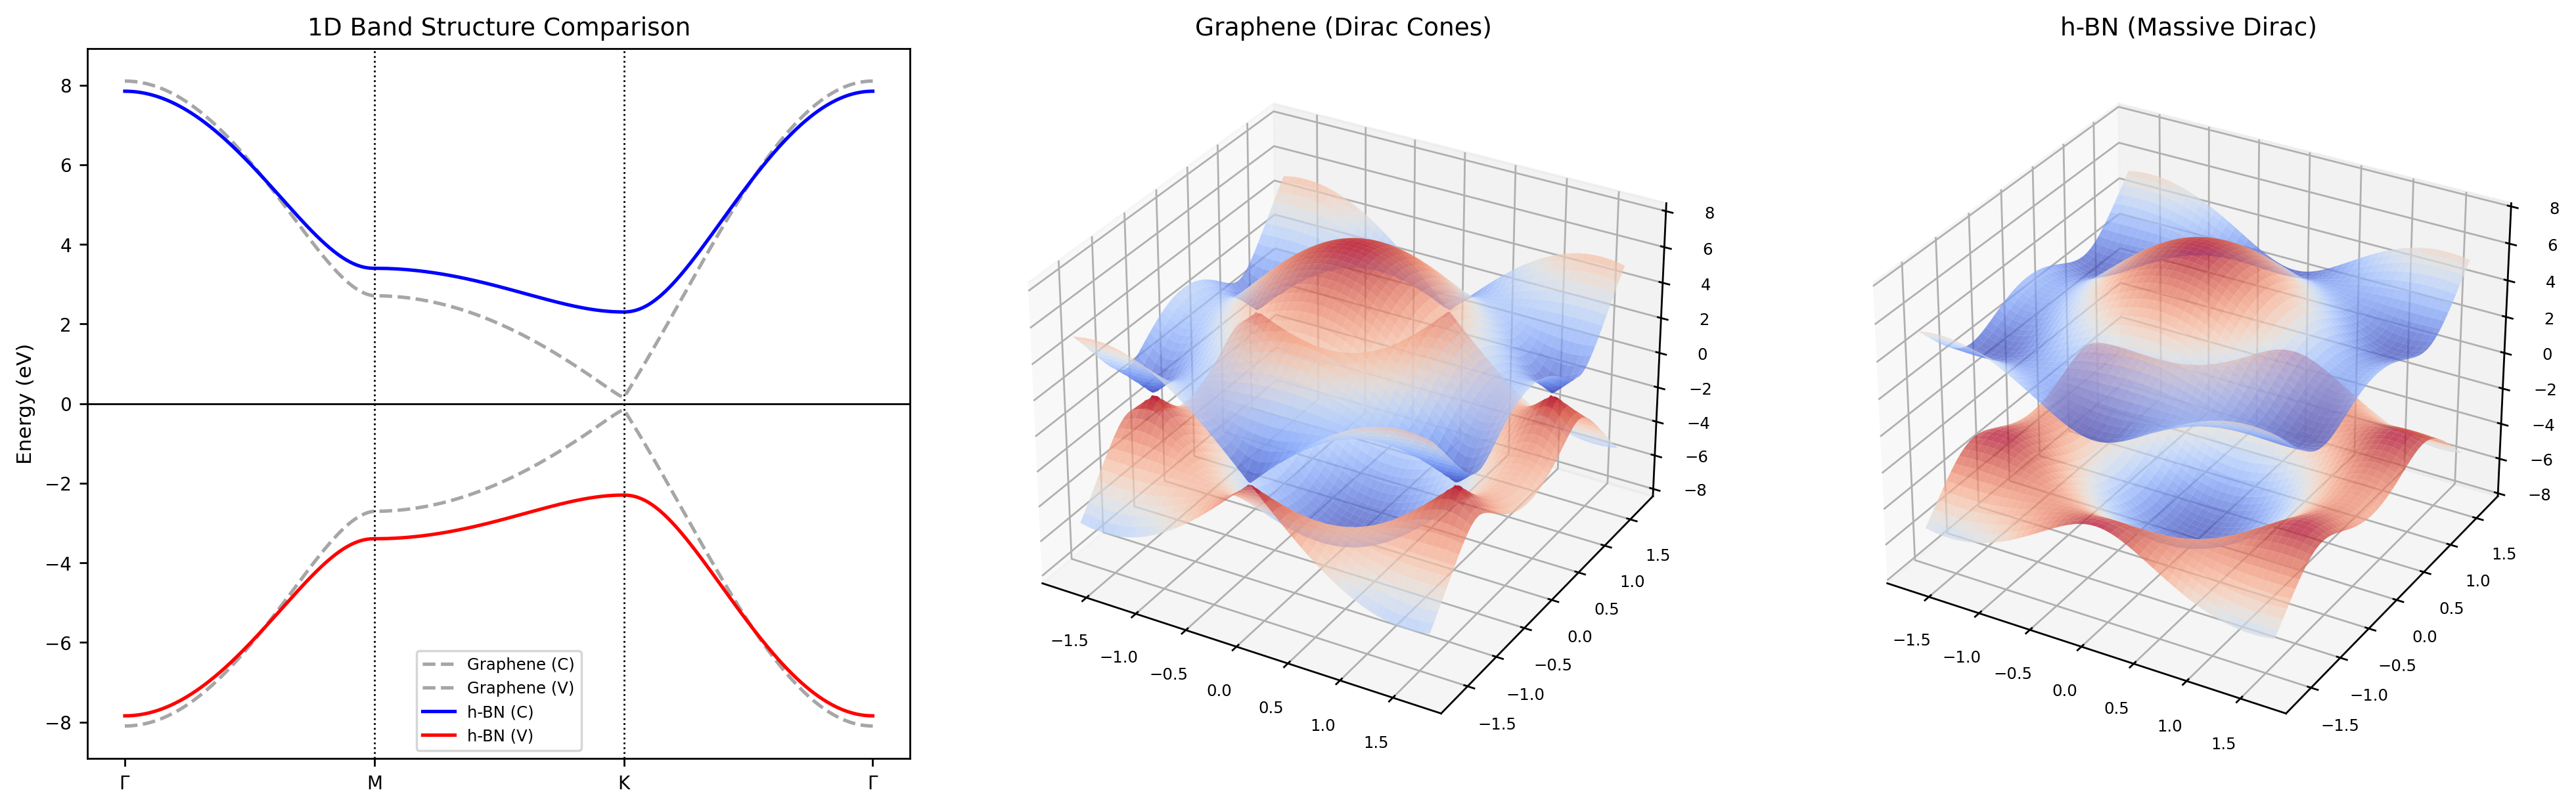

In [1]:
"""
Comparison of electronic band structures: Graphene vs. Hexagonal Boron Nitride (h-BN).

This script evaluates the tight-binding Hamiltonian for both materials to visualize
how the on-site energy difference in h-BN opens a band gap compared to the
zero-gap Dirac cones of Graphene.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# =============================================================================
# CONTROL KNOBS
# =============================================================================
# Graphene Parameters
T_GR: float = 2.7          # eV
A_GR: float = 2.46         # Angstroms

# h-BN Parameters
T_BN: float = 2.5          # eV
DELTA_BN: float = 4.6       # eV (On-site energy difference)
A_BN: float = 2.50         # Angstroms

# General Settings
RES_1D: int = 300
RES_2D: int = 150
PLOT_DPI: int = 250
FONT_SIZE: int = 9

# =============================================================================
# Apply rendering preferences
# =============================================================================
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.size'] = FONT_SIZE

def calc_energy(k_x, k_y, t, delta, a):
    """
    Unified tight-binding energy calculation for honeycomb lattices.
    delta = 0 for Graphene, delta > 0 for h-BN.
    """
    term1 = 4.0 * np.cos(np.sqrt(3.0) * k_x * a / 2.0) * np.cos(k_y * a / 2.0)
    term2 = 4.0 * np.cos(k_y * a / 2.0)**2
    f_k_squared = 1.0 + term1 + term2

    # The general formula: E = +/- sqrt( (delta/2)^2 + t^2 * f(k)^2 )
    return np.sqrt((delta / 2.0)**2 + (t**2) * f_k_squared)

def render_comparison() -> None:
    # We use a wider figure to accommodate three plots (1D, 3D Graphene, 3D h-BN)
    fig = plt.figure(figsize=(16, 5))

    # ---------------------------------------------------------
    # 1. OVERLAID 1D Band Structure
    # ---------------------------------------------------------
    ax1 = fig.add_subplot(131)

    # We use h-BN's lattice constant for the x-axis scale to keep it consistent
    gamma = np.array([0.0, 0.0])
    m_point = np.array([2.0 * np.pi / (np.sqrt(3.0) * A_BN), 0.0])
    k_point = np.array([2.0 * np.pi / (np.sqrt(3.0) * A_BN), 2.0 * np.pi / (3.0 * A_BN)])

    path_g_m = np.linspace(gamma, m_point, RES_1D)
    path_m_k = np.linspace(m_point, k_point, RES_1D)
    path_k_g = np.linspace(k_point, gamma, RES_1D)
    k_path = np.vstack((path_g_m, path_m_k, path_k_g))
    x_axis = np.arange(len(k_path))

    # Compute Graphene Energies (delta = 0)
    e_gr_cond = calc_energy(k_path[:, 0], k_path[:, 1], T_GR, 0, A_GR)
    e_gr_val = -e_gr_cond

    # Compute h-BN Energies (delta = DELTA_BN)
    e_bn_cond = calc_energy(k_path[:, 0], k_path[:, 1], T_BN, DELTA_BN, A_BN)
    e_bn_val = -e_bn_cond

    # Plot Graphene in Grey/Black
    ax1.plot(x_axis, e_gr_cond, color='grey', linestyle='--', label='Graphene (C)', alpha=0.7)
    ax1.plot(x_axis, e_gr_val, color='grey', linestyle='--', label='Graphene (V)', alpha=0.7)

    # Plot h-BN in Blue/Red
    ax1.plot(x_axis, e_bn_cond, color='blue', linewidth=1.5, label='h-BN (C)')
    ax1.plot(x_axis, e_bn_val, color='red', linewidth=1.5, label='h-BN (V)')

    # Formatting
    ax1.axhline(0, color='k', linestyle='-', linewidth=0.8)
    ax1.axvline(RES_1D, color='k', linestyle=':', linewidth=0.8)
    ax1.axvline(2 * RES_1D, color='k', linestyle=':', linewidth=0.8)
    ax1.set_xticks([0, RES_1D, 2 * RES_1D, len(k_path) - 1])
    ax1.set_xticklabels([r'$\Gamma$', 'M', 'K', r'$\Gamma$'])
    ax1.set_ylabel("Energy (eV)")
    ax1.set_title("1D Band Structure Comparison")
    ax1.legend(fontsize=FONT_SIZE - 2)
    ax1.tick_params(labelsize=FONT_SIZE - 1)
    ax1.grid(False)

    # ---------------------------------------------------------
    # 2. 3D Surface Plot: Graphene
    # ---------------------------------------------------------
    ax2 = fig.add_subplot(132, projection='3d')
    k_ext_gr = 4.0 * np.pi / (3.0 * A_GR)
    kx_gr = np.linspace(-k_ext_gr, k_ext_gr, RES_2D)
    ky_gr = np.linspace(-k_ext_gr, k_ext_gr, RES_2D)
    kx_m_gr, ky_m_gr = np.meshgrid(kx_gr, ky_gr)

    e_surf_gr = calc_energy(kx_m_gr, ky_m_gr, T_GR, 0, A_GR)
    ax2.plot_surface(kx_m_gr, ky_m_gr, e_surf_gr, cmap=cm.coolwarm, alpha=0.7, antialiased=True)
    ax2.plot_surface(kx_m_gr, ky_m_gr, -e_surf_gr, cmap=cm.coolwarm, alpha=0.7, antialiased=True)
    ax2.set_title("Graphene (Dirac Cones)")
    ax2.tick_params(labelsize=FONT_SIZE - 2)

    # ---------------------------------------------------------
    # 3. 3D Surface Plot: h-BN
    # ---------------------------------------------------------
    ax3 = fig.add_subplot(133, projection='3d')
    k_ext_bn = 4.0 * np.pi / (3.0 * A_BN)
    kx_bn = np.linspace(-k_ext_bn, k_ext_bn, RES_2D)
    ky_bn = np.linspace(-k_ext_bn, k_ext_bn, RES_2D)
    kx_m_bn, ky_m_bn = np.meshgrid(kx_bn, ky_bn)

    e_surf_bn = calc_energy(kx_m_bn, ky_m_bn, T_BN, DELTA_BN, A_BN)
    ax3.plot_surface(kx_m_bn, ky_m_bn, e_surf_bn, cmap=cm.coolwarm, alpha=0.7, antialiased=True)
    ax3.plot_surface(kx_m_bn, ky_m_bn, -e_surf_bn, cmap=cm.coolwarm, alpha=0.7, antialiased=True)
    ax3.set_title("h-BN (Massive Dirac)")
    ax3.tick_params(labelsize=FONT_SIZE - 2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_comparison()